In [1]:
import pathlib
import numpy as np
import pandas as pd

pd.set_option('display.max_columns', None)
pd.set_option('display.max_rows', None)
from prepare import process_regressor, model_performance_metrics,draw_scatter
from data_prune_function import get_scores,get_data,prune_rd,return_model
random_state =352
test_size = 0.1

model = {}
for modelname in ['CB','XG','GB']:
    model[modelname] = return_model(modelname,random_state=random_state)

target = 'NO(%)'
df,X,y,X_train_val,X_test,y_train_val,y_test = get_data(target = target,random_state=random_state, test_size=test_size,standardized=False)
mad = (y - y.mean()).abs().mean()
std = y.std()
print('')
print('-----------------')
print(f'{target} {y.shape[0]} {mad:.3f} {std:.3f} ')
print('-----------------')
target = 'NO(%)'
a = 'CB'
b = 'XG'
c = 'GB'


-----------------
NO(%) 242 14.156 17.853 
-----------------


In [2]:
from prepare import bootstrap_predict_ci

In [3]:
mean_pred, lower, upper, preds = bootstrap_predict_ci(
    model['CB'],
    X_train_val, y_train_val,
    X_test,
    n_boot=10,
    alpha=0.05,
    random_state=42
)

平均CI宽度: 9.48713613849112


In [4]:
from prepare import draw_scatter

cv train R2: 0.685 (+/- 0.094) 

Cat Train mse: 0.00019 | rmse: 0.01389 | mae: 0.01068 | mape: 2.69917 | smape: 2.67146 | r2: 0.99380

Cat Test mse: 0.00383 | rmse: 0.06187 | mae: 0.04682 | mape: 14.87899 | smape: 13.21868 | r2: 0.89445



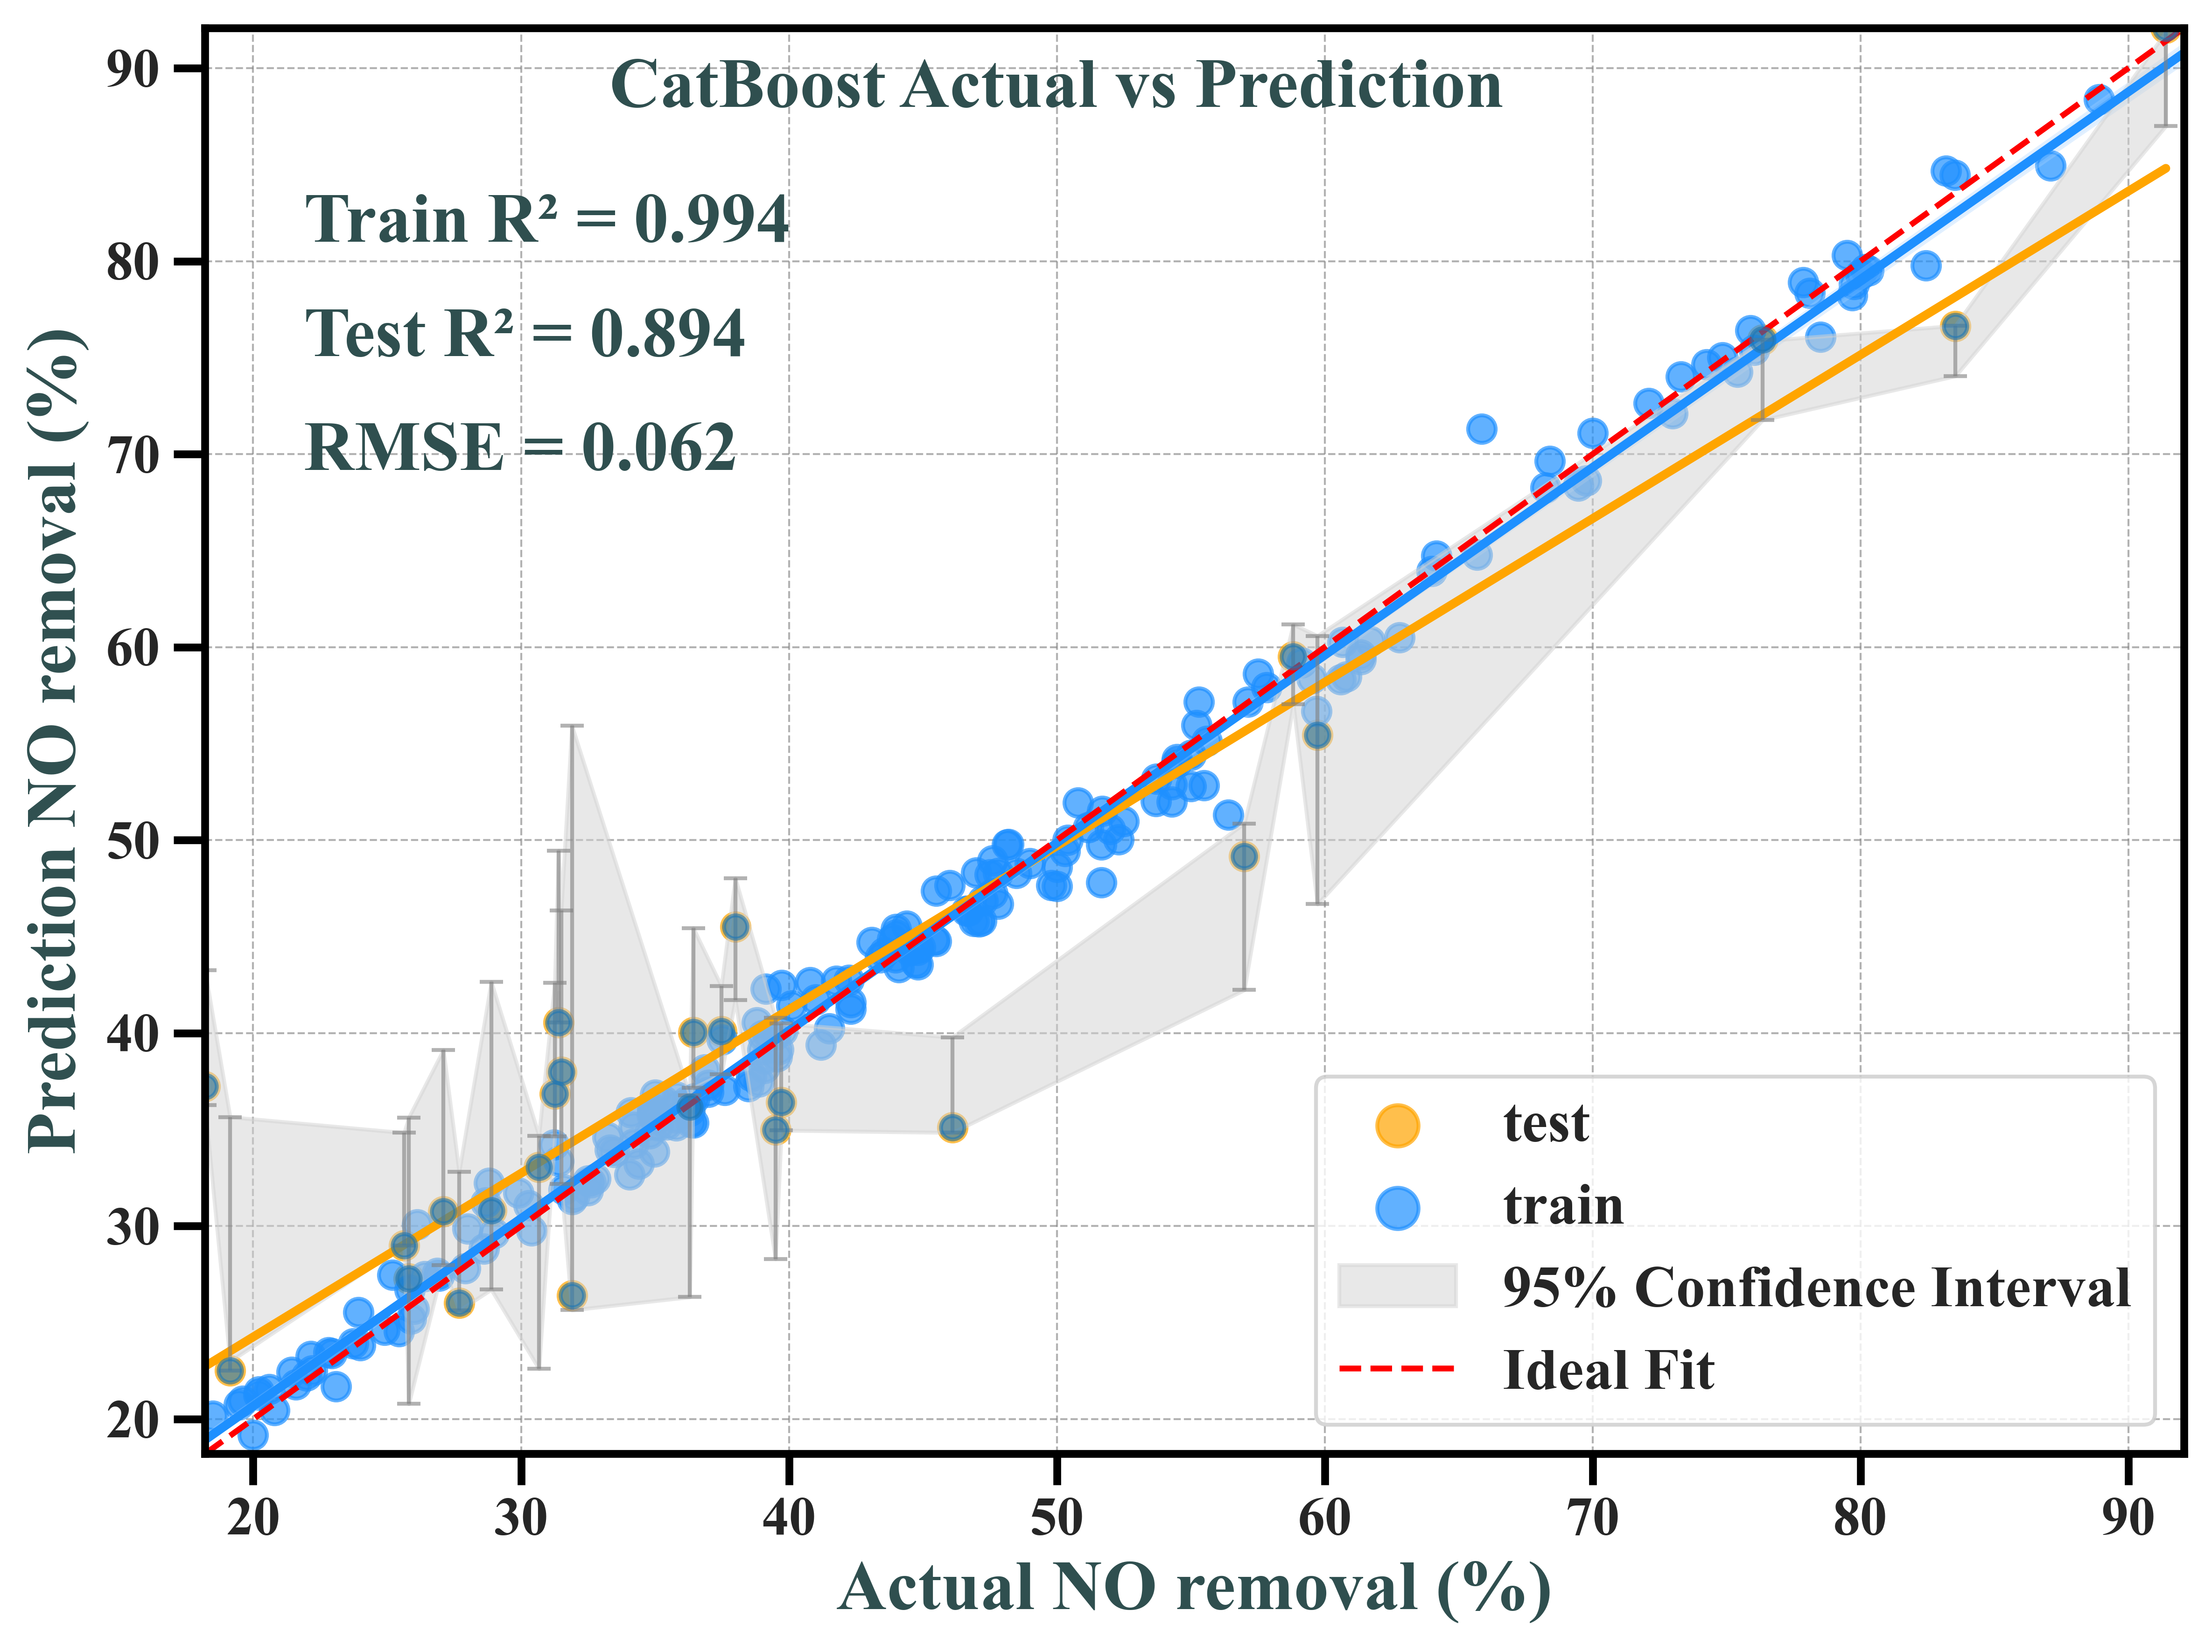

In [5]:
train_pred, test_pred = process_regressor(model[a],X_train_val,X_test,y_train_val,y_test)
model_performance_metrics('Cat Train', y_train_val, train_pred)
model_performance_metrics('Cat Test', y_test, test_pred)
draw_scatter(y_train_val, train_pred, y_test,test_pred,
                 title = 'CatBoost Actual vs Prediction',
                 test_lower=lower, test_upper=upper,
                 train_lower=None, train_upper=None,
                 actual_text='Actual NO removal (%)', pred_text='Prediction NO removal (%)',
                 save=True)

平均CI宽度: 11.086333
cv train R2: 0.659 (+/- 0.098) 

Cat Train mse: 0.00063 | rmse: 0.02513 | mae: 0.01943 | mape: 5.04504 | smape: 4.94009 | r2: 0.97969

Cat Test mse: 0.00443 | rmse: 0.06657 | mae: 0.05010 | mape: 15.07566 | smape: 13.30395 | r2: 0.87779



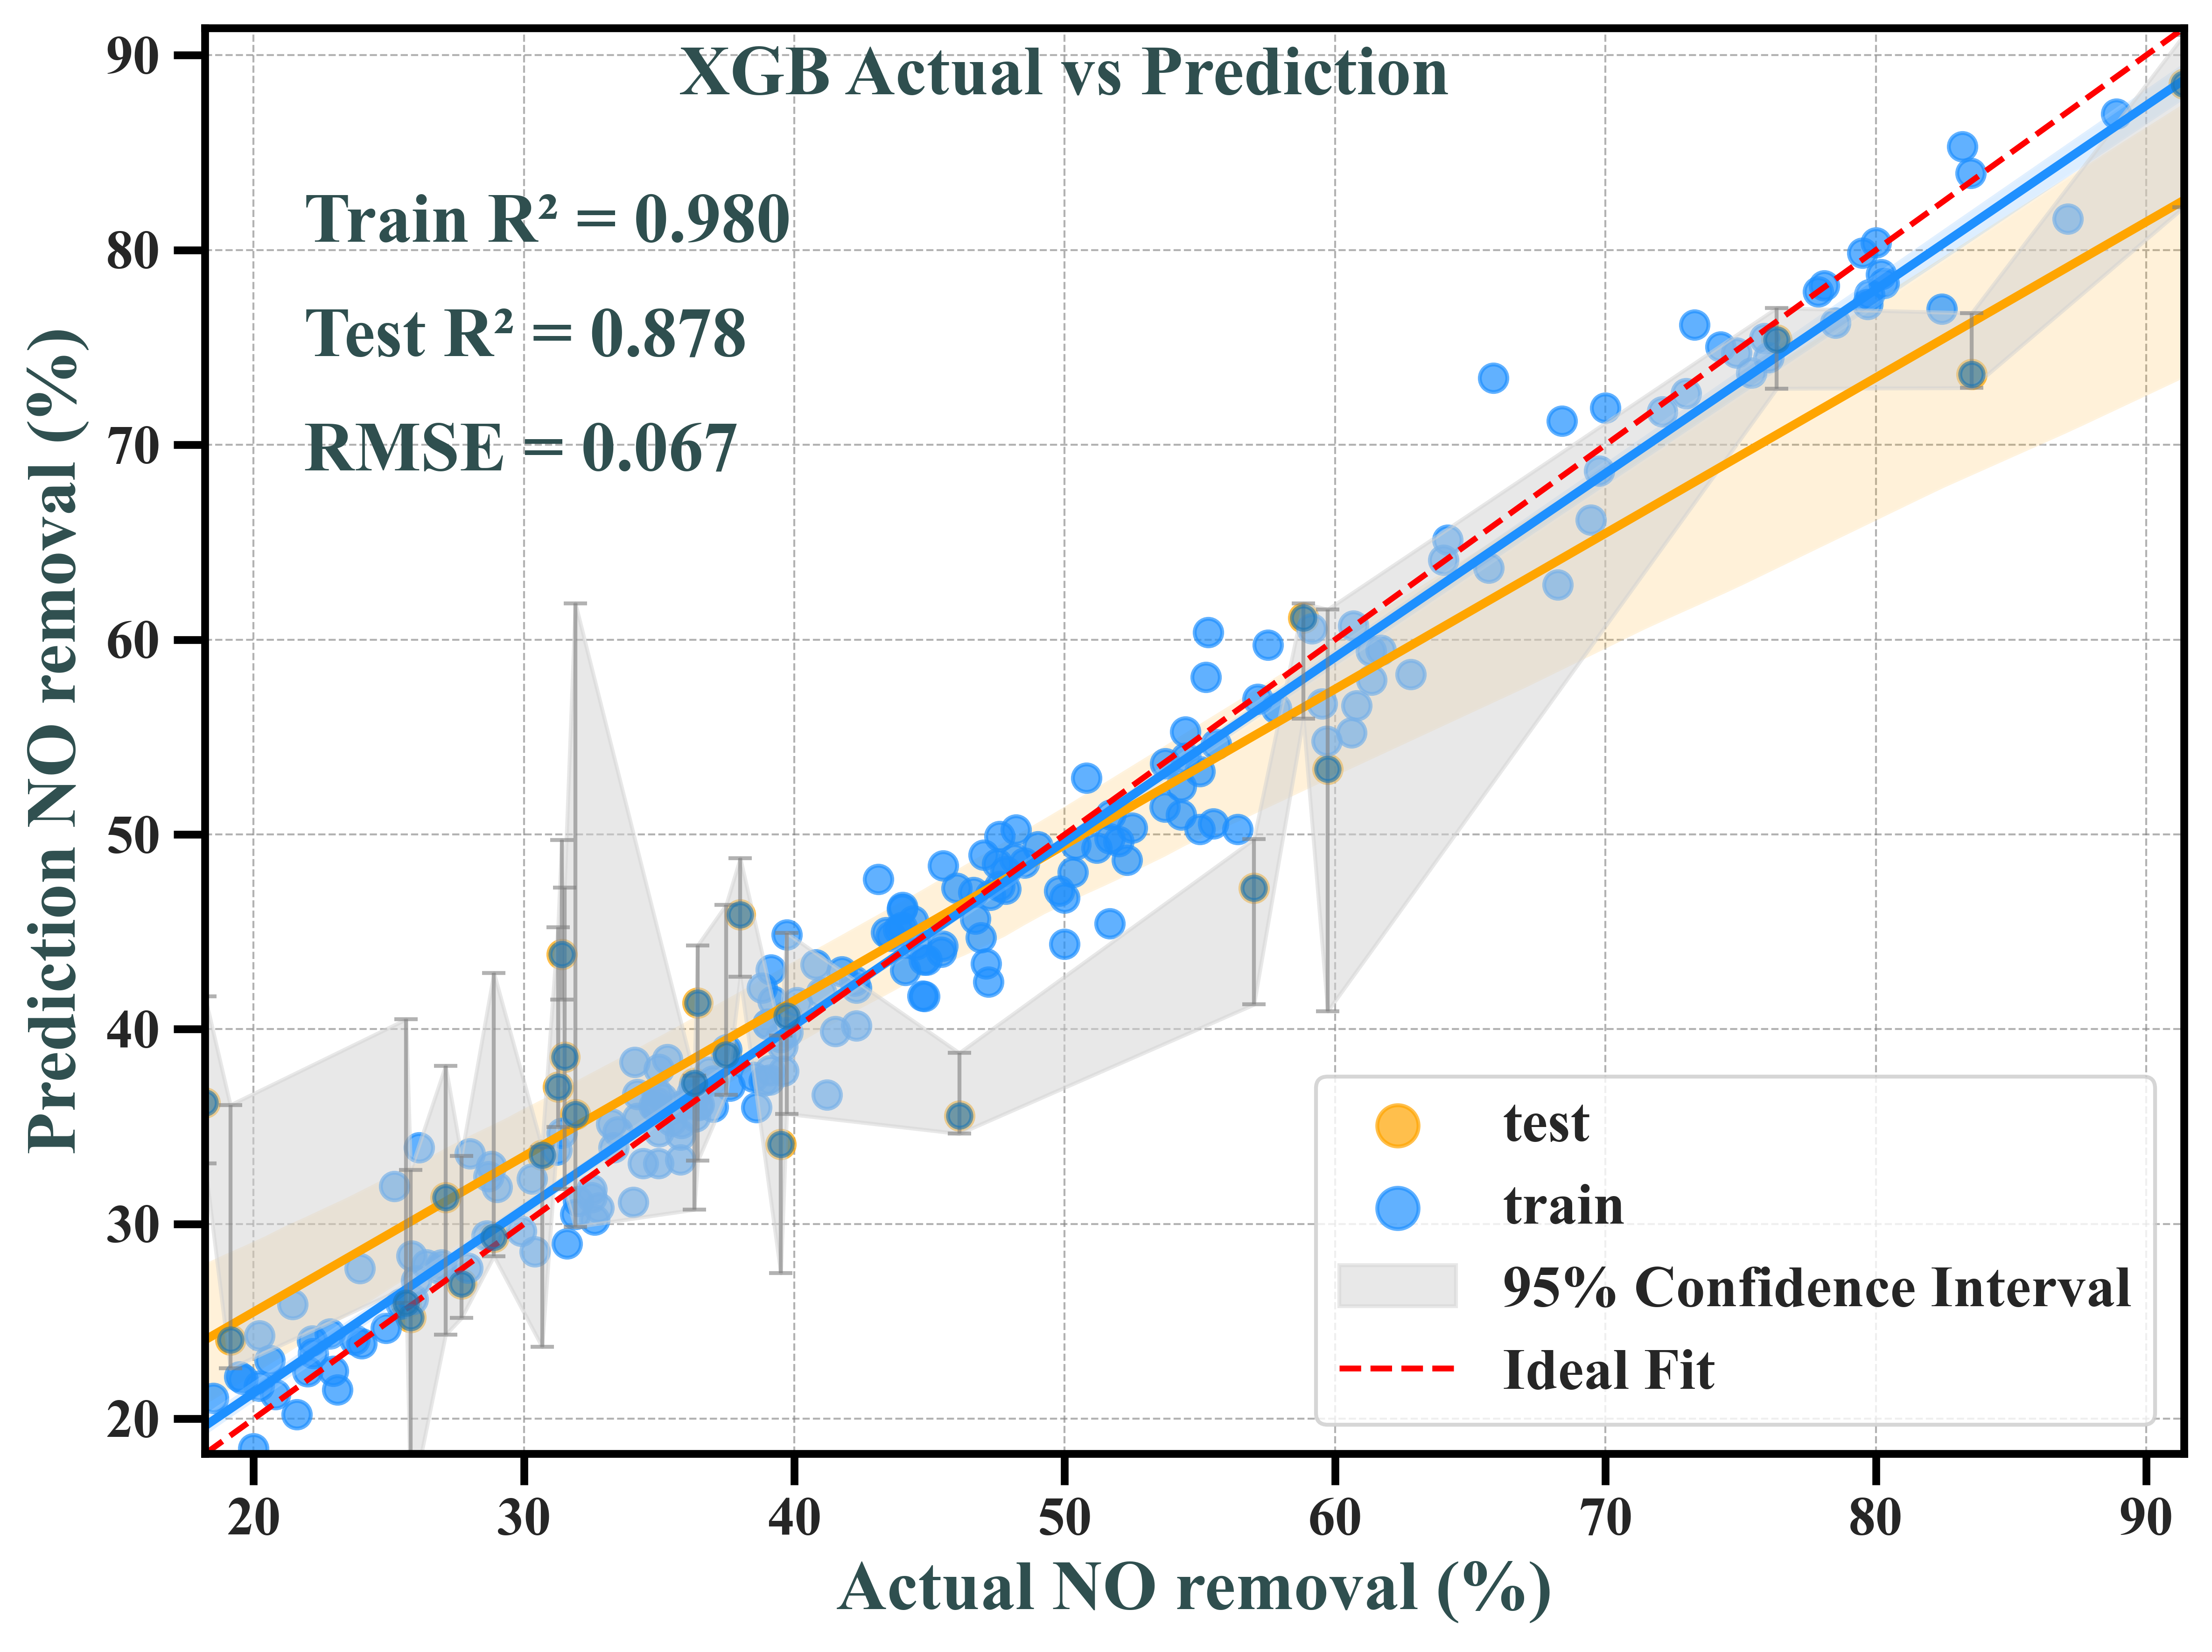

In [7]:
mean_pred, lower, upper, preds = bootstrap_predict_ci(
    model[b],
    X_train_val, y_train_val,
    X_test,
    n_boot=10,
    alpha=0.05,
    random_state=42
)
train_pred, test_pred = process_regressor(model[b],X_train_val,X_test,y_train_val,y_test)
model_performance_metrics('Cat Train', y_train_val, train_pred)
model_performance_metrics('Cat Test', y_test, test_pred)
draw_scatter(y_train_val, train_pred, y_test,test_pred,
                 title = 'XGB Actual vs Prediction',
                 test_lower=lower, test_upper=upper,
                 train_lower=None, train_upper=None,
                 actual_text='Actual NO removal (%)', pred_text='Prediction NO removal (%)',
                 save=True)

平均CI宽度: 11.086333
cv train R2: 0.682 (+/- 0.111) 

Cat Train mse: 0.00001 | rmse: 0.00341 | mae: 0.00276 | mape: 0.69936 | smape: 0.69737 | r2: 0.99963

Cat Test mse: 0.00470 | rmse: 0.06857 | mae: 0.05218 | mape: 16.74918 | smape: 14.90412 | r2: 0.87036



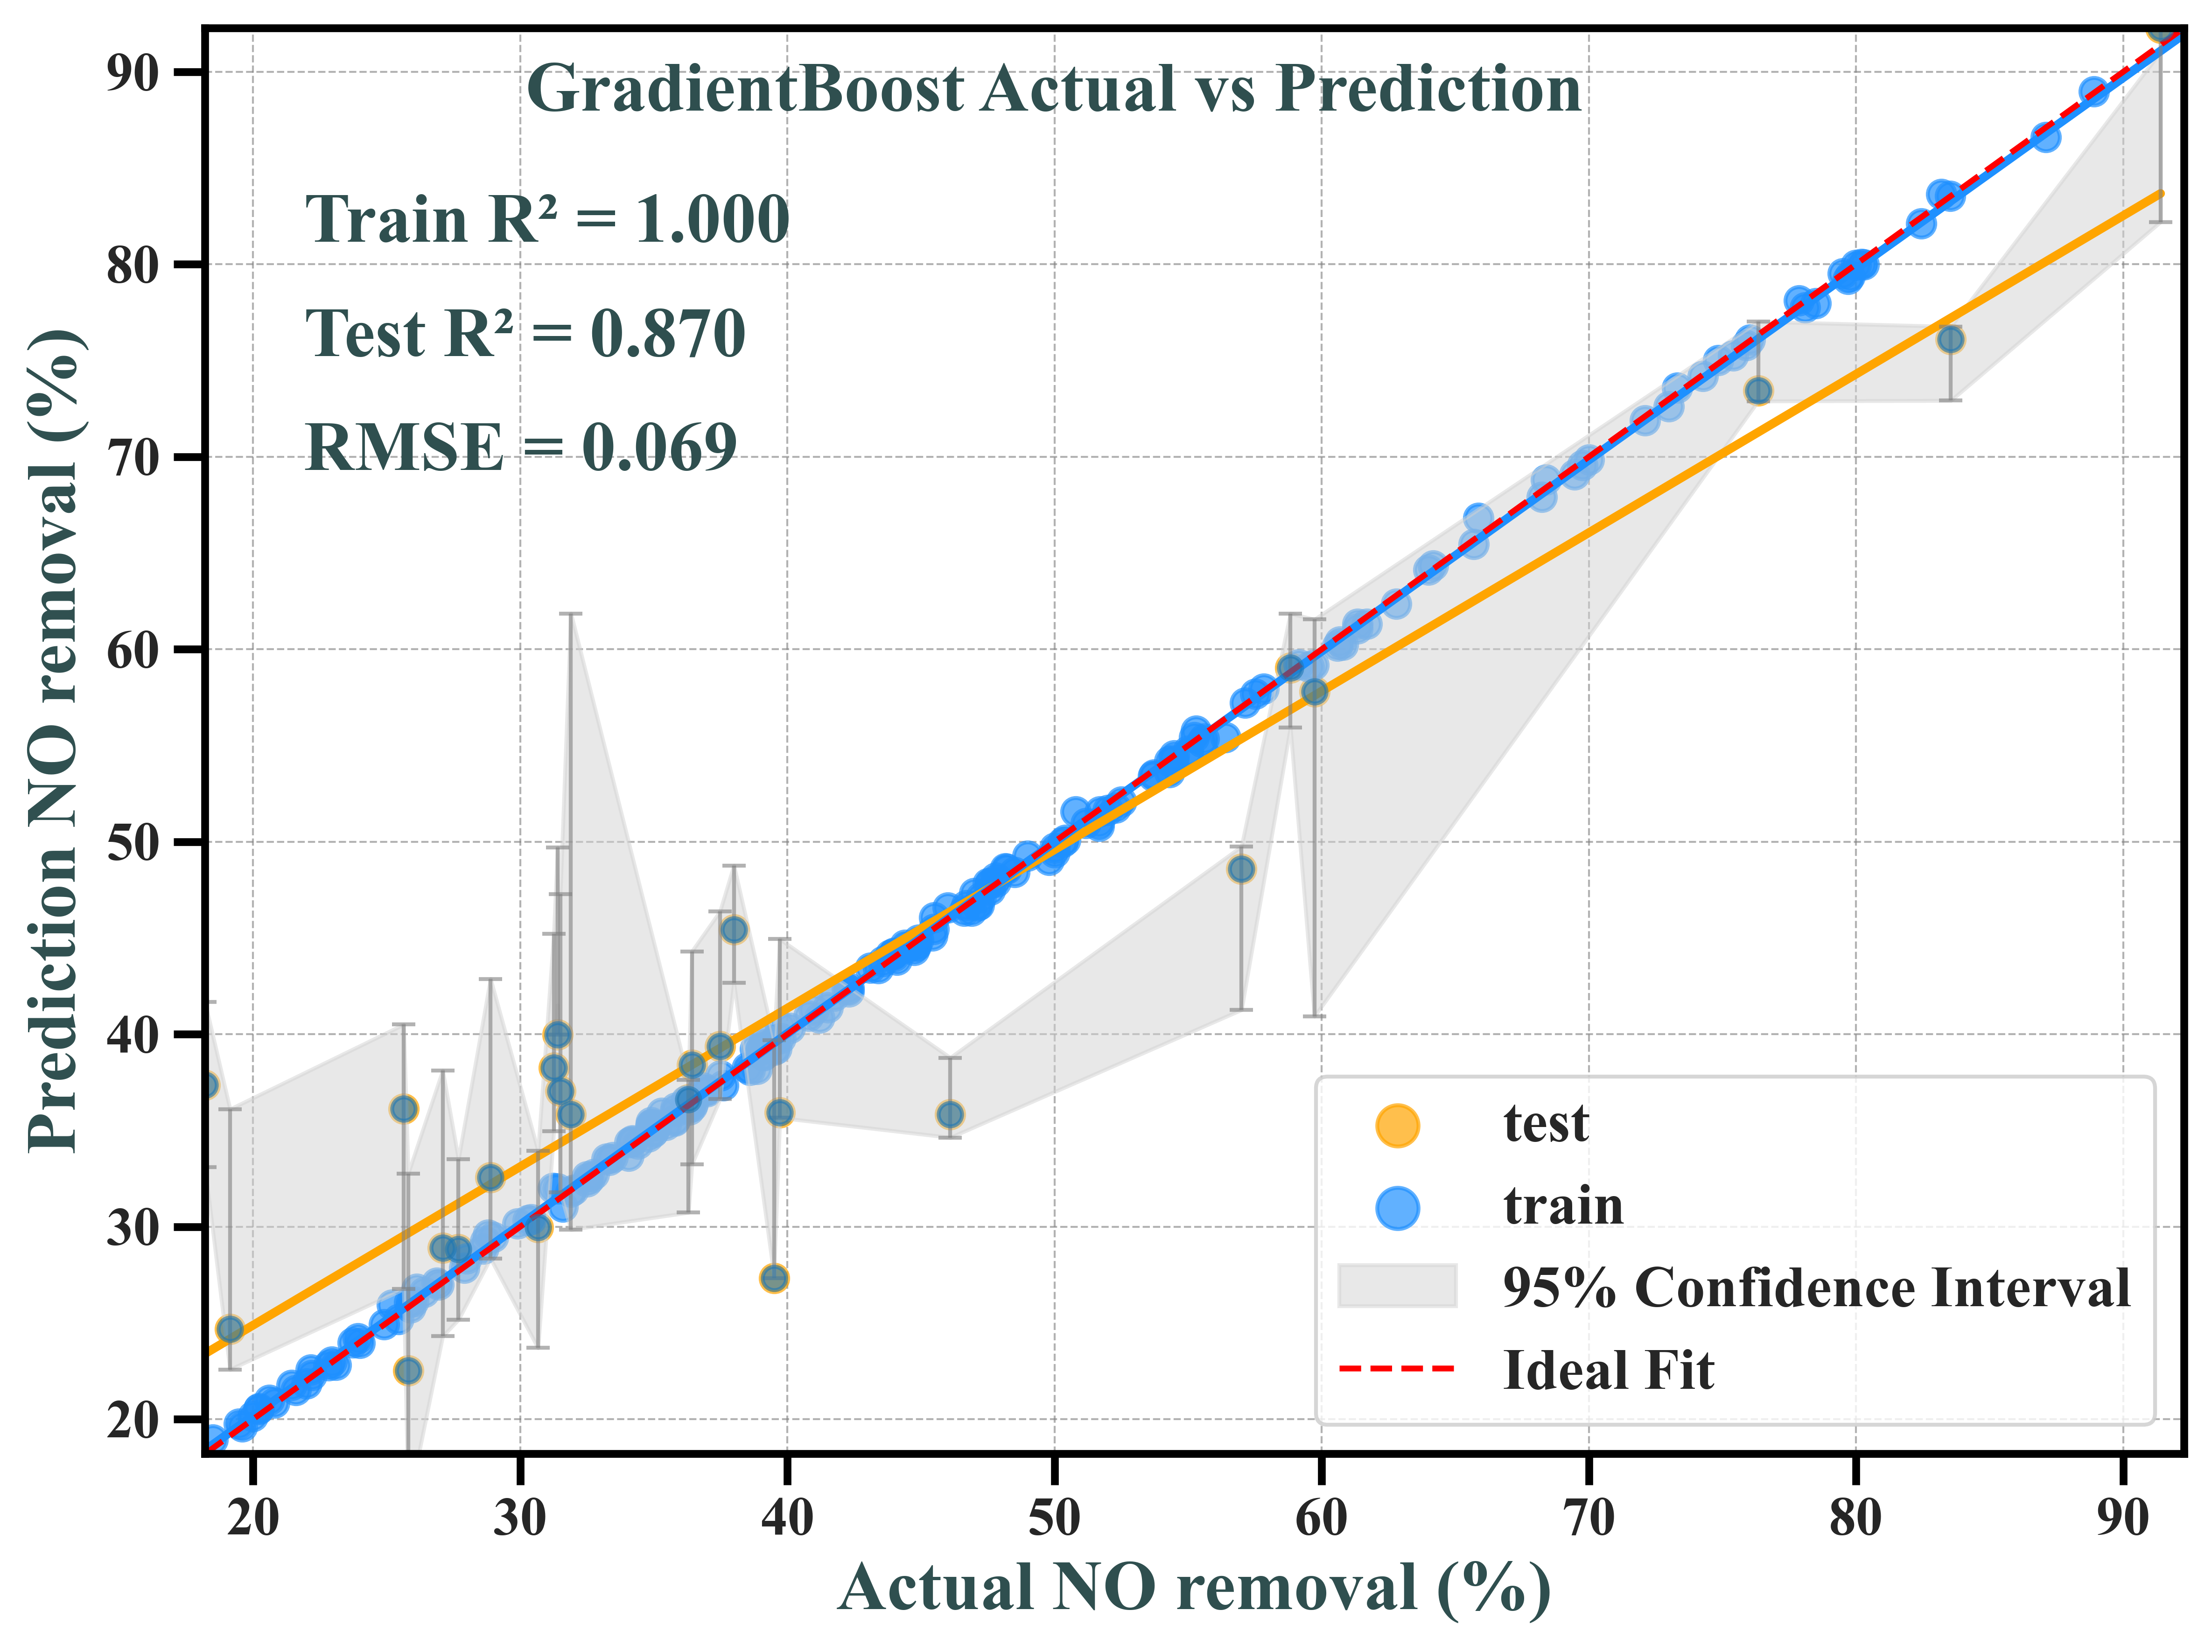

In [6]:
mean_pred, lower, upper, preds = bootstrap_predict_ci(
    model['XG'],
    X_train_val, y_train_val,
    X_test,
    n_boot=10,
    alpha=0.05,
    random_state=42
)
train_pred, test_pred = process_regressor(model[c],X_train_val,X_test,y_train_val,y_test)
model_performance_metrics('Cat Train', y_train_val, train_pred)
model_performance_metrics('Cat Test', y_test, test_pred)
draw_scatter(y_train_val, train_pred, y_test,test_pred,
                 title = 'GradientBoost Actual vs Prediction',
                 test_lower=lower, test_upper=upper,
                 train_lower=None, train_upper=None,
                 actual_text='Actual NO removal (%)', pred_text='Prediction NO removal (%)',
                 save=True)

In [13]:
folder = f'{target}/{target}_{a}_guiding_pruning'
pathlib.Path(f"./{folder}").mkdir(parents=True, exist_ok=True)
file_out_a = f'{folder}/all_dat.pkl'

folder = f'{target}/{target}_{b}_guiding_pruning'
pathlib.Path(f"./{folder}").mkdir(parents=True, exist_ok=True)
file_out_b = f'{folder}/all_dat.pkl'

folder = f'{target}/{target}_{c}_guiding_pruning'
pathlib.Path(f"./{folder}").mkdir(parents=True, exist_ok=True)
file_out_c = f'{folder}/all_dat.pkl'

In [14]:
maes_a, rmse_a, r2_a = get_scores(model[a], X_train_val, y_train_val, X_test, y_test)
maes_b, rmse_b, r2_b = get_scores(model[b], X_train_val, y_train_val, X_test, y_test)
maes_c, rmse_c, r2_c = get_scores(model[c], X_train_val, y_train_val, X_test, y_test)

Test scores: MAE=4.682, RMSE=6.187, R2=0.894
--- 0.7670598030090332 seconds ---

Test scores: MAE=5.010, RMSE=6.657, R2=0.878
--- 0.11341166496276855 seconds ---

Test scores: MAE=5.218, RMSE=6.857, R2=0.870
--- 0.1182394027709961 seconds ---



In [16]:
size_old_val_a, ids_a, test_scores_a, val_scores_a,test_fit_a,remove_a = prune_rd(
        model[a], X_train_val, y_train_val, X_test, y_test,max_iter=80,
        min_drop= 2,
        threshold=maes_a / 2,train_size= 0.9, file_out=file_out_a)

Iteration 0:
丢弃训练词条数量 : 4 
本次循环中 old_val 数量: 0 (ratio = 0.000)
本次循环中新训练集大小，占比: 217  (ratio = 1.000)
--- 0.7091774940490723 seconds ---
修剪模型：
Test scores: maes=4.616, rmse=5.952, r2=0.902
--- 0.7721335887908936 seconds ---
Iteration 1:
丢弃训练词条数量 : 4 
本次循环中 old_val 数量: 4 (ratio = 0.018)
本次循环中新训练集大小，占比: 213  (ratio = 0.982)
--- 0.7549636363983154 seconds ---
修剪模型：
Test scores: maes=4.761, rmse=6.143, r2=0.896
Val scores: maes=0.916, rmse=1.228, r2=0.996
--- 0.714597225189209 seconds ---
Iteration 2:
丢弃训练词条数量 : 4 
本次循环中 old_val 数量: 8 (ratio = 0.037)
本次循环中新训练集大小，占比: 209  (ratio = 0.963)
--- 0.7129337787628174 seconds ---
修剪模型：
Test scores: maes=4.604, rmse=6.107, r2=0.897
Val scores: maes=1.305, rmse=1.535, r2=0.989
--- 0.792478084564209 seconds ---
Iteration 3:
丢弃训练词条数量 : 4 
本次循环中 old_val 数量: 12 (ratio = 0.055)
本次循环中新训练集大小，占比: 205  (ratio = 0.945)
--- 0.6656625270843506 seconds ---
修剪模型：
Test scores: maes=4.724, rmse=6.249, r2=0.892
Val scores: maes=1.931, rmse=2.388, r2=0.982
--- 0.6690602

In [17]:
size_old_val_b, ids_b, test_scores_b, val_scores_b,test_fit_b,remove_b = prune_rd(
    model[b], X_train_val, y_train_val, X_test, y_test,max_iter=80,min_drop= 2,threshold=maes_b / 2,train_size= 0.9, file_out=file_out_b)

Iteration 0:
丢弃训练词条数量 : 3 
本次循环中 old_val 数量: 0 (ratio = 0.000)
本次循环中新训练集大小，占比: 217  (ratio = 1.000)
--- 0.12431144714355469 seconds ---
修剪模型：
Test scores: maes=4.679, rmse=6.627, r2=0.879
--- 0.08859038352966309 seconds ---
Iteration 1:
丢弃训练词条数量 : 3 
本次循环中 old_val 数量: 3 (ratio = 0.014)
本次循环中新训练集大小，占比: 214  (ratio = 0.986)
--- 0.08235692977905273 seconds ---
修剪模型：
Test scores: maes=4.850, rmse=6.583, r2=0.881
Val scores: maes=1.333, rmse=1.345, r2=0.997
--- 0.08889603614807129 seconds ---
Iteration 2:
丢弃训练词条数量 : 4 
本次循环中 old_val 数量: 6 (ratio = 0.028)
本次循环中新训练集大小，占比: 211  (ratio = 0.972)
--- 0.08897519111633301 seconds ---
修剪模型：
Test scores: maes=5.021, rmse=6.925, r2=0.868
Val scores: maes=2.694, rmse=3.108, r2=0.974
--- 0.09098458290100098 seconds ---
Iteration 3:
丢弃训练词条数量 : 4 
本次循环中 old_val 数量: 10 (ratio = 0.046)
本次循环中新训练集大小，占比: 207  (ratio = 0.954)
--- 0.08722996711730957 seconds ---
修剪模型：
Test scores: maes=4.627, rmse=6.383, r2=0.888
Val scores: maes=2.024, rmse=2.403, r2=0.977
--- 

In [18]:
size_old_val_c, ids_c, test_scores_c, val_scores_c,test_fit_c,remove_c = prune_rd(
        model[c], X_train_val, y_train_val, X_test, y_test,max_iter=80,
        min_drop= 2,threshold=maes_c / 2,train_size= 0.9, file_out=file_out_c)

Iteration 0:
丢弃训练词条数量 : 4 
本次循环中 old_val 数量: 0 (ratio = 0.000)
本次循环中新训练集大小，占比: 217  (ratio = 1.000)
--- 0.1382143497467041 seconds ---
修剪模型：
Test scores: maes=4.817, rmse=6.352, r2=0.889
--- 0.12159967422485352 seconds ---
Iteration 1:
丢弃训练词条数量 : 6 
本次循环中 old_val 数量: 4 (ratio = 0.018)
本次循环中新训练集大小，占比: 213  (ratio = 0.982)
--- 0.11360764503479004 seconds ---
修剪模型：
Test scores: maes=5.053, rmse=6.589, r2=0.880
Val scores: maes=2.788, rmse=3.570, r2=0.953
--- 0.12018728256225586 seconds ---
Iteration 2:
丢弃训练词条数量 : 6 
本次循环中 old_val 数量: 10 (ratio = 0.046)
本次循环中新训练集大小，占比: 207  (ratio = 0.954)
--- 0.1060028076171875 seconds ---
修剪模型：
Test scores: maes=4.936, rmse=6.514, r2=0.883
Val scores: maes=2.695, rmse=3.171, r2=0.933
--- 0.11390352249145508 seconds ---
Iteration 3:
丢弃训练词条数量 : 6 
本次循环中 old_val 数量: 16 (ratio = 0.074)
本次循环中新训练集大小，占比: 201  (ratio = 0.926)
--- 0.10786676406860352 seconds ---
修剪模型：
Test scores: maes=5.646, rmse=7.298, r2=0.853
Val scores: maes=2.570, rmse=3.157, r2=0.965
--- 0

In [40]:
from prepare import get_mse_rmse_mae_mape_smape_r2
import os
from matplotlib import pyplot as plt
import seaborn as sns
from matplotlib.ticker import MultipleLocator

def draw_scatter_1(train_true, train_pred, val_true, val_pred,
                   test_true, test_pred, title,
                   test_lower=None, test_upper=None,
                   actual_text='actual', pred_text='prediction',
                   save=False):
    """
    绘制三组数据的散点图（训练集、验证集、测试集）
    仅在测试集上添加误差区间和误差棒
    """

    # 统一字体设置
    plt.rcParams['font.family'] = 'Times New Roman'

    # 转成一维数组，避免 pandas / ndarray 混用出错
    train_true = np.asarray(train_true).ravel()
    train_pred = np.asarray(train_pred).ravel()
    val_true = np.asarray(val_true).ravel()
    val_pred = np.asarray(val_pred).ravel()
    test_true = np.asarray(test_true).ravel()
    test_pred = np.asarray(test_pred).ravel()

    if test_lower is not None:
        test_lower = np.asarray(test_lower).ravel()
    if test_upper is not None:
        test_upper = np.asarray(test_upper).ravel()

    # 创建图形
    fig, ax = plt.subplots(figsize=(10, 8))

    # 定义字体样式
    font_common = {
        'family': 'Times New Roman',
        'color': '#2F4F4F',
        'weight': 'bold',
        'size': 18
    }
    legend_font = {'family': 'Times New Roman', 'weight': 'bold', 'size': 15}

    # ===== 先画训练集、验证集回归散点图（基础内容不变）=====
    sns.regplot(x=train_true, y=train_pred,
                color="dodgerblue", label='train',
                scatter_kws={'alpha': 0.5, 's': 18},
                ax=ax)

    sns.regplot(x=val_true, y=val_pred,
                color="orange", label="val",
                scatter_kws={'alpha': 0.5, 's': 10},
                ax=ax)

    sns.regplot(x=test_true, y=test_pred,
                color='#FF69B4', label='test',
                scatter_kws={'alpha': 0.8, 's': 30},
                ax=ax)

    # ===== 只对测试集添加误差区间和误差棒 =====
    if test_lower is not None and test_upper is not None:
        # 按真实值排序，保证阴影区间平滑
        sorted_idx = np.argsort(test_true)
        test_true_sorted = test_true[sorted_idx]
        test_pred_sorted = test_pred[sorted_idx]
        lower_sorted = test_lower[sorted_idx]
        upper_sorted = test_upper[sorted_idx]

        # 计算误差棒上下长度
        yerr_lower = np.maximum(test_pred_sorted - lower_sorted, 0)
        yerr_upper = np.maximum(upper_sorted - test_pred_sorted, 0)

        # 置信区间阴影
        ax.fill_between(
            test_true_sorted,
            lower_sorted,
            upper_sorted,
            color='lightgray',
            alpha=0.5,
            label='95% Confidence Interval',
            zorder=1
        )

        # 误差棒
        ax.errorbar(
            test_true_sorted,
            test_pred_sorted,
            yerr=[yerr_lower, yerr_upper],
            fmt='o',
            markersize=4,
            color='#FF69B4',
            ecolor='gray',
            elinewidth=1,
            capsize=3,
            alpha=0.7,
            zorder=2
        )

    # ===== 坐标轴标签和范围 =====
    ax.set_xlabel(actual_text, fontdict=font_common, weight='bold')
    ax.set_ylabel(pred_text, fontdict=font_common, weight='bold')
    ax.set_xlim(15, 95)
    ax.set_ylim(15, 95)

    # 图例
    ax.legend(loc="lower right", markerscale=1.5, prop=legend_font,
              frameon=True)

    # 刻度
    ax.tick_params(axis='both', which='major', direction='out',
                   width=2, labelsize=16,
                   bottom=True, top=False, left=True, right=False)
    ax.tick_params(axis='both', which='minor', direction='out',
                   bottom=True, top=False, left=True, right=False)
    for label in ax.get_xticklabels() + ax.get_yticklabels():
        label.set_fontsize(16)      # 放大字体
        label.set_fontweight('bold')  # 加粗
        label.set_family('Times New Roman')
    ax.xaxis.set_major_locator(MultipleLocator(10))
    ax.yaxis.set_major_locator(MultipleLocator(10))
    ax.xaxis.set_minor_locator(MultipleLocator(10))
    ax.yaxis.set_minor_locator(MultipleLocator(10))

    # 背景和边框
    ax.set_facecolor('white')
    for spine in ax.spines.values():
        spine.set_linewidth(3)
        spine.set_edgecolor('black')

    # 网格
    ax.grid(True, axis='both', linestyle='--',
            linewidth=0.5, color='gray', alpha=0.6)

    # ===== 统计信息 =====
    _, _, _, _, _, train_r2 = get_mse_rmse_mae_mape_smape_r2(
        train_true / 100, train_pred / 100
    )
    _, _, _, _, _, val_r2 = get_mse_rmse_mae_mape_smape_r2(
        val_true / 100, val_pred / 100
    )
    _, _, _, _, _, test_r2 = get_mse_rmse_mae_mape_smape_r2(
        test_true / 100, test_pred / 100
    )

    ax.text(20, 86, f"Train R² = {train_r2:.3f}", **font_common)
    ax.text(20, 80, f"val   R² = {val_r2:.3f}", **font_common)
    ax.text(20, 74, f"test  R² = {test_r2:.3f}", **font_common)

    # 标题
    ax.text(50, 90, title, **font_common, horizontalalignment="center")

    # 保存
    if save:
        out_put = 'scatter_images'
        if not os.path.exists(out_put):
            os.makedirs(out_put)
        output_path = os.path.join(out_put, f'{title}.jpg')
        plt.savefig(output_path, format="jpg", dpi=600,
                    bbox_inches="tight",
                    pil_kwargs={'quality': 95})
        print(f"测试图已保存：{output_path}")

    plt.tight_layout()
    plt.show()

In [19]:
a_test_70 = list(set(ids_a['train_val']) - set(remove_a[20]))
b_test_70 = list(set(ids_b['train_val']) - set(remove_b[21]))
c_test_70 = list(set(ids_c['train_val']) - set(remove_c[20]))

In [26]:
df_a = df.loc[remove_a[20]]
X_train_val = df_a.drop(columns=['NO(%)'])
y_train_val = df_a['NO(%)']
df_a_val = df.loc[a_test_70]
X_val = df_a_val.drop(columns=['NO(%)'])
y_val = df_a_val['NO(%)']
train_pred, val_pred = process_regressor(model[a],X_train_val,X_val,y_train_val,y_val,cv=False)
_,test_pred = process_regressor(model[a],X_train_val,X_test,y_train_val,y_test,cv=False)
model_performance_metrics('Cat Train 70%', y_train_val, train_pred)
model_performance_metrics('Cat val 30%', y_val, val_pred)
model_performance_metrics('Cat test', y_test, test_pred)

In [30]:
mean_pred, lower, upper, preds = bootstrap_predict_ci(
    model[a],
    X_train_val, y_train_val,
    X_test,
    n_boot=1000,
    alpha=0.05,
    random_state=42
)

平均CI宽度: 18.837178269837796


测试图已保存：scatter_images\Catboost prune 70%.jpg


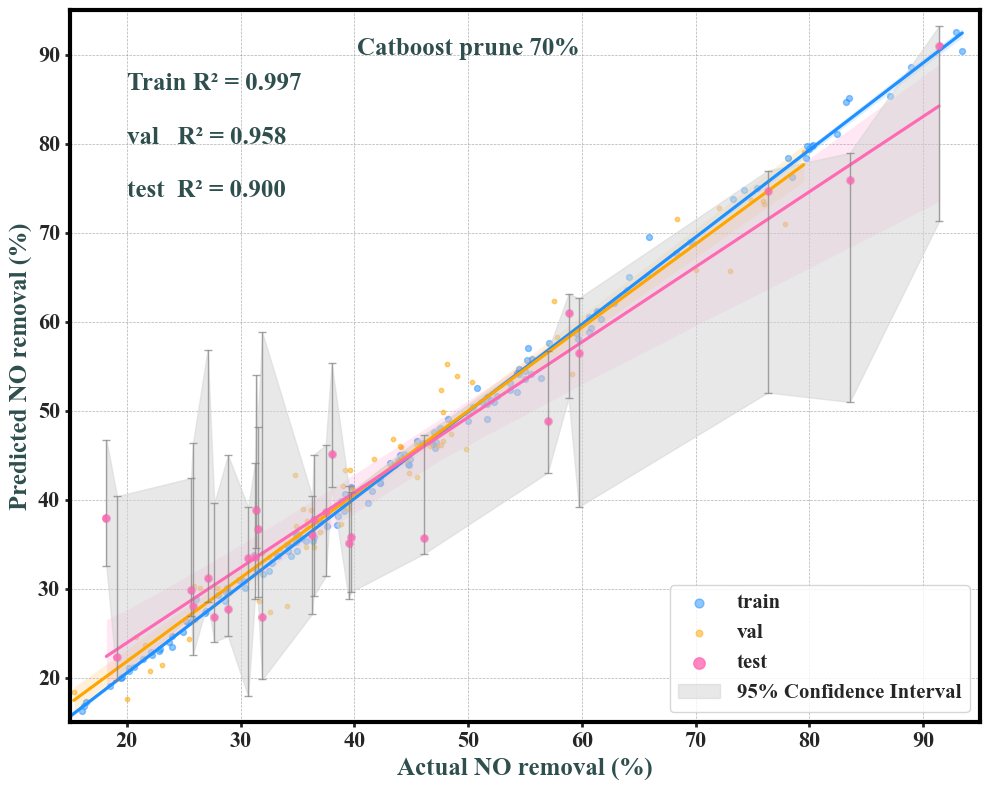

In [41]:
draw_scatter_1(y_train_val, train_pred, y_val,val_pred,y_test, test_pred, "Catboost prune 70%", actual_text='Actual NO removal (%)',test_lower=lower,test_upper=upper,pred_text='Predicted NO removal (%)',save=True)

cv train R2: -0.134 (+/- 0.403) 

cv train R2: -0.134 (+/- 0.403) 

XGB Train 70% mse: 0.00055 | rmse: 0.02335 | mae: 0.01842 | mape: 4.81955 | smape: 4.71416 | r2: 0.98366

XGB val 30% mse: 0.00154 | rmse: 0.03923 | mae: 0.03110 | mape: 7.62827 | smape: 7.54193 | r2: 0.94022

XGB test mse: 0.00456 | rmse: 0.06756 | mae: 0.05200 | mape: 15.17046 | smape: 13.55697 | r2: 0.87413

测试图已保存：scatter_images\XGBboost prune 70%.jpg


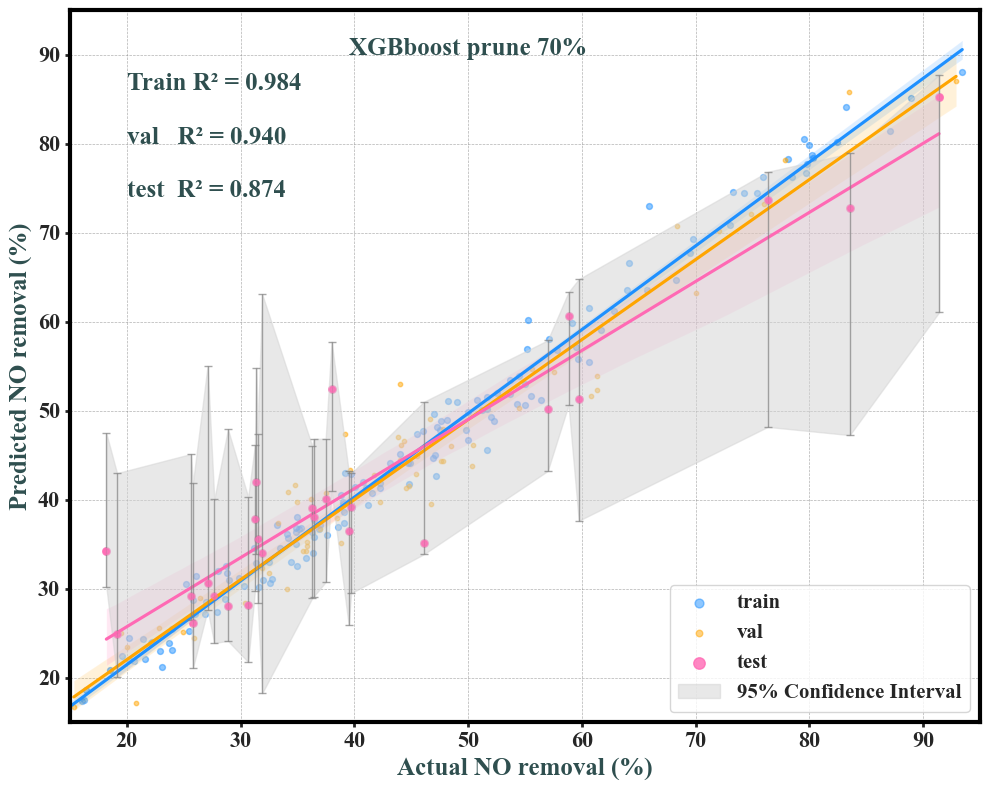

In [48]:
df_b = df.loc[remove_b[21]]
X_train_val = df_b.drop(columns=['NO(%)'])
y_train_val = df_b['NO(%)']
df_b_val = df.loc[b_test_70]
X_val = df_b_val.drop(columns=['NO(%)'])
y_val = df_b_val['NO(%)']
train_pred, val_pred = process_regressor(model[b],X_train_val,X_val,y_train_val,y_val)
_,test_pred = process_regressor(model[b],X_train_val,X_test,y_train_val,y_test)
model_performance_metrics('XGB Train 70%', y_train_val, train_pred)
model_performance_metrics('XGB val 30%', y_val, val_pred)
model_performance_metrics('XGB test', y_test, test_pred)

平均CI宽度: 21.134958
测试图已保存：scatter_images\XGBboost prune 70%.jpg


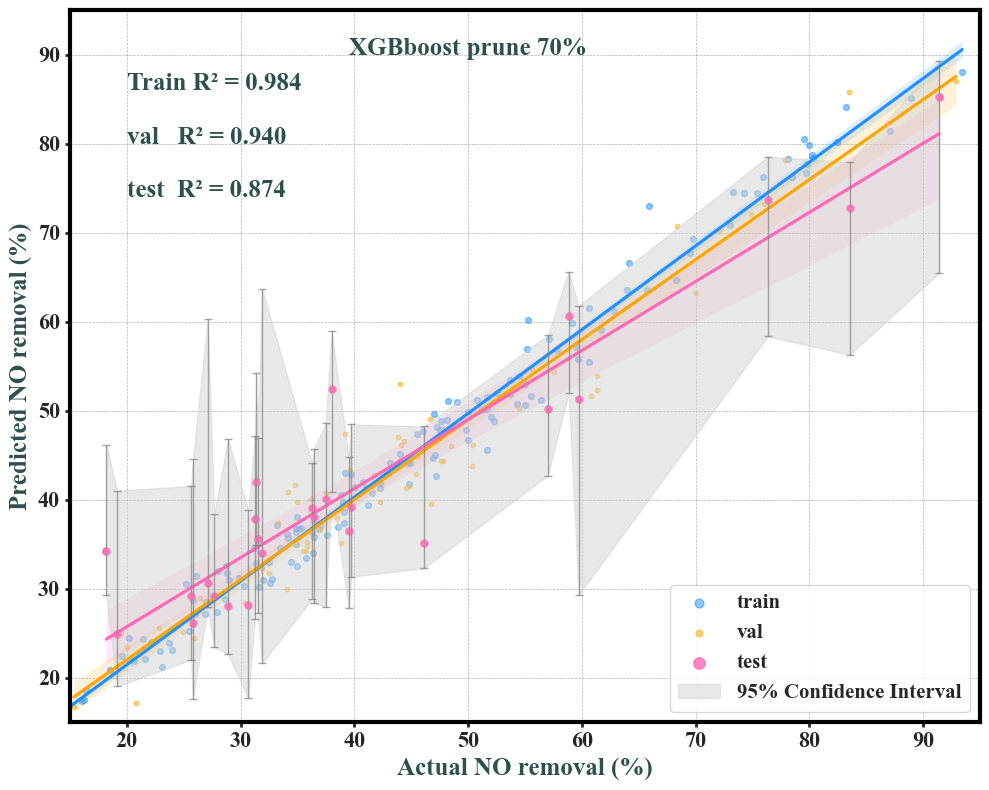

In [49]:
mean_pred, lower, upper, preds = bootstrap_predict_ci(
    model[b],
    X_train_val, y_train_val,
    X_test,
    n_boot=1000,
    alpha=0.05,
    random_state=42
)
draw_scatter_1(y_train_val, train_pred, y_val,val_pred,y_test, test_pred, "XGBboost prune 70%", actual_text='Actual NO removal (%)',test_lower=lower,test_upper=upper,pred_text='Predicted NO removal (%)',save=True)

In [44]:
df_c = df.loc[remove_c[20]]
X_train_val = df_c.drop(columns=['NO(%)'])
y_train_val = df_c['NO(%)']
df_c_val = df.loc[c_test_70]
X_val = df_c_val.drop(columns=['NO(%)'])
y_val = df_c_val['NO(%)']
train_pred, val_pred = process_regressor(model[c],X_train_val,X_val,y_train_val,y_val,cv=True)
_,test_pred = process_regressor(model[c],X_train_val,X_test,y_train_val,y_test,cv=True)
model_performance_metrics('GradientBoost Train 70%', y_train_val, train_pred)
model_performance_metrics('GradientBoost val 30%', y_val, val_pred)
model_performance_metrics('GradientBoost test', y_test, test_pred)

cv train R2: 0.009 (+/- 0.226) 

cv train R2: 0.009 (+/- 0.226) 

GradientBoost Train 70% mse: 0.00001 | rmse: 0.00331 | mae: 0.00275 | mape: 0.70646 | smape: 0.70440 | r2: 0.99968

GradientBoost val 30% mse: 0.00170 | rmse: 0.04118 | mae: 0.03227 | mape: 8.54976 | smape: 8.37605 | r2: 0.92516

GradientBoost test mse: 0.00465 | rmse: 0.06819 | mae: 0.05461 | mape: 17.10435 | smape: 15.35287 | r2: 0.87179



0.8717884702170781

In [47]:
mean_pred, lower, upper, preds = bootstrap_predict_ci(
    model[c],
    X_train_val, y_train_val,
    X_test,
    n_boot=1000,
    alpha=0.05,
    random_state=42
)

平均CI宽度: 20.951681323093293


测试图已保存：scatter_images\GradientBoost prune 70%.jpg


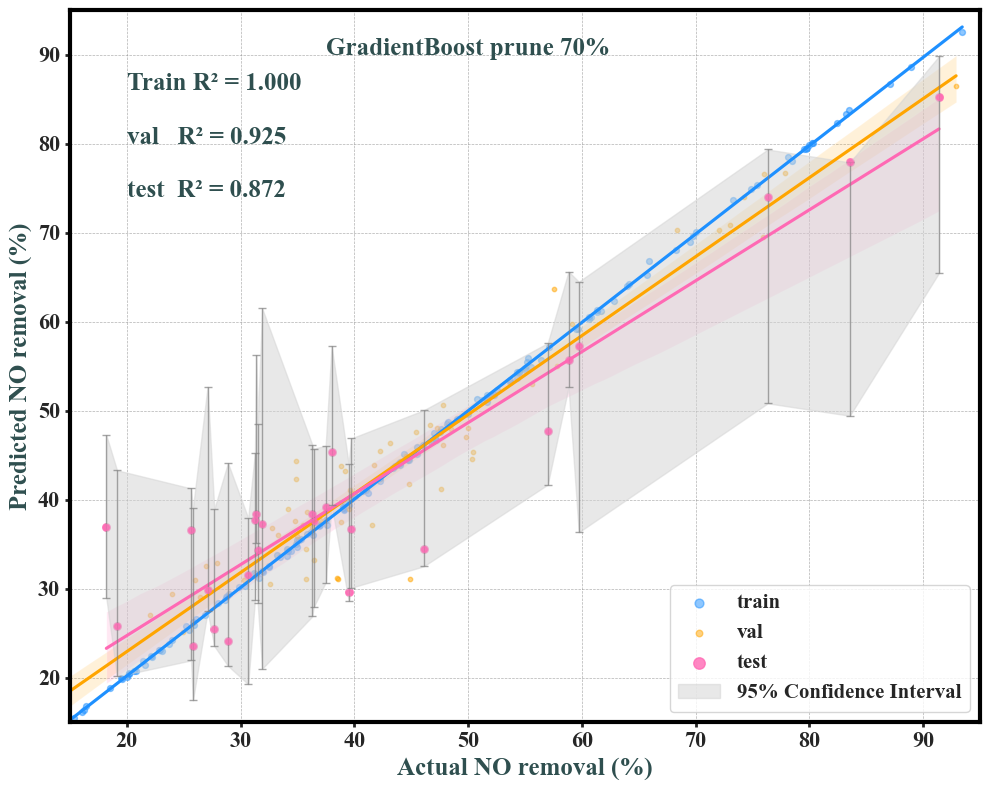

In [46]:
draw_scatter_1(y_train_val, train_pred, y_val,val_pred,y_test, test_pred, "GradientBoost prune 70%", actual_text='Actual NO removal (%)',test_lower=lower,test_upper=upper,pred_text='Predicted NO removal (%)',save=True)